# 07 · Stability, confounds, sensitivity analyses and limitations (protocol §7.5, §8–10)

## 1. Prediction stability
Repeated CV tests each participant **once per repeat**, so with 10 repeats every participant has 10 out-of-sample decision scores per model. For each participant we report:
- **Mean decision score:** how confidently the model places them, averaged over partitions.
- **SD of the decision score:** how much the prediction depends on *which other participants* were in the training set. This is the **primary** stability summary.
- **Classification frequency:** the share of repeats in which they were called a patient at the fold's threshold. It is a secondary summary, because a thresholded label hides changes in confidence: a score moving from +0.05 to +2.0 is still "patient" both times.

Participants who are consistently misclassified, or whose predictions are unstable, are worth describing, since they may be atypical cases.

## 2. Feature stability
- **With feature selection:** stability would be the **selection frequency**, i.e. how often each feature is selected across folds. The primary analysis selects no features, so there are no "selected features" in the strict sense.
- **Without selection:** stability is assessed on the **weight vectors** recovered from each of the 50 outer-fold models (notebook 04):
  - **cosine similarity** between the weight vectors of different fits, from 1 (identical direction) down to 0 (unrelated);
  - **sign consistency**, the share of fits in which a feature's weight has the same sign as its mean weight;
  - **network/region aggregation**, averaging edge weights within pairs of Yeo networks (functional) or reporting them per Desikan–Killiany region (structural).
- **Why aggregate.** Correlated connections can **swap weight** between folds: if two edges carry the same information, one fold may lean on the first and another fold on the second. Individual weights look unstable even when the model relies on the same *system*. Aggregating to networks averages out these swaps (Demo 2).
- **Weights ≠ biology.** The weights of a linear classifier also act to cancel noise, so a large weight does not mean a region "differs" between groups (Haufe et al., 2014). Feature-level stability is **not** read as evidence of biological specificity.

## 3. Confounds
A **confound** is a variable related both to diagnosis and to the MRI features. A classifier can then separate the groups by detecting the confound, for example head motion, rather than the illness. The protocol addresses each potential confound explicitly:

| Factor | Why it matters | Handling |
|---|---|---|
| **Age** | brain structure and connectivity change with age; groups may differ in age | described by group; in the confound set |
| **Sex** | head size and some brain measures differ by sex | described; in the confound set; area and volume divided by eTIV |
| **Medication** | antipsychotics can change brain structure and function; nearly all patients are medicated | described if available. Medication cannot be separated from diagnosis, so this is stated as a limitation rather than regressed out |
| **Head motion** | inflates or deflates connectivity; patients often move more | QC exclusion, censoring, mean FD in the confound set, stringent-motion sensitivity analysis |
| **Signal-to-noise ratio** | noisier data give noisier features | BOLD tSNR and FreeSurfer surface holes described and in the confound set |
| **Missingness** | who gets excluded can differ by group | complete cases, no imputation, exclusions reported by reason (notebook 01) |
| **Class imbalance** | can bias accuracy and PR-AUC | stratified splits, balanced class weights, PR-AUC chance level |
| **Scanner/acquisition** | different scanners or protocols create group-specific signal | verified single scanner (notebook 01); if not, scanner is added as a confound |
| **Diagnostic/recruitment differences** | mixing schizophrenia with schizoaffective disorder; different recruitment pathways | strict-schizophrenia sensitivity analysis; subgroups described |

### Confound-only baseline
A linear SVM trained only on the confound set (age, sex, mean FD, eTIV, surface holes, tSNR) is run through the identical nested pipeline. If it performs well, the non-imaging and data-quality variables alone can predict diagnosis, and imaging results must be read with that in mind.

### Cross-validated confound regression
To remove a confound from the features:
1. regress each feature on the confounds using **training-fold participants only**, and keep the slopes;
2. subtract the confound-explained part from both training and test participants, using those same slopes.

Fitting the regression on *all* participants would leak test information, and it has been shown to bias results in both directions (Snoek, Miletić & Scholte, 2019). This is what the `*_residualized` sensitivity models do.

## 4. Sensitivity analyses (reported regardless of outcome; none replaces the primary analysis)
1. **Confound-only baseline:** can confounds alone predict diagnosis?
2. **Residualized imaging:** functional and MKL models with confounds regressed out inside the training folds.
3. **Alternative denoising:** no censoring (`simple`), and censoring plus global signal regression.
4. **Strict schizophrenia labels:** schizoaffective patients removed.
5. **Stringent motion:** participants with mean FD > 0.25 mm excluded.
6. **Alternative MKL estimator:** centered-kernel-alignment weights instead of the inner-CV grid.
7. **Threshold 0:** threshold-based metrics at the SVM's own boundary.

A result that holds across these analyses is robust to the corresponding choices. A result that changes shows which choice it depends on.

In [1]:
from pathlib import Path
from functools import partial
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
RESULTS = ROOT / "results"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
use_notebook("06_metrics_and_statistical_inference.ipynb")   # metrics + permutations (+ notebooks 04, 05)

In [3]:
def prediction_stability(predictions, model):
    """Per participant: mean and SD of the out-of-sample score, and how often called a patient."""
    subset = predictions[predictions["model"] == model]
    return (subset.groupby("participant_id")
            .agg(y_true=("y_true", "first"), mean_score=("score", "mean"), sd_score=("score", "std"),
                 n_scores=("score", "size"), frac_predicted_patient=("y_pred", "mean"))
            .reset_index())


def load_weights(path):
    """{(model, repeat, fold, modality): weight vector} from a primal_weights*.npz file."""
    out = {}
    with np.load(path) as data:
        for key in data.files:
            model, repeat, fold, modality = key.split("__")
            out[(model, int(repeat[1:]), int(fold[1:]), modality)] = data[key]
    return out


def weight_matrix(weights, model, modality):
    keys = sorted(k for k in weights if k[0] == model and k[3] == modality)
    return np.vstack([weights[k] for k in keys]) if keys else np.empty((0, 0))


def cosine_similarity_matrix(W):
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    unit = W / np.where(norms > 0, norms, 1.0)
    return unit @ unit.T


def mean_pairwise_similarity(W):
    S = cosine_similarity_matrix(W)
    return float(S[np.triu_indices(len(W), k=1)].mean())


def sign_consistency(W):
    """Per feature: share of fits whose weight has the sign of the mean weight."""
    return (np.sign(W) == np.sign(W.mean(axis=0))).mean(axis=0)


def selection_frequency(masks):
    """Per-feature selection frequency, for exploratory analyses that do select features."""
    return np.asarray(masks, dtype=float).mean(axis=0)


def network_aggregate(w, edges):
    """Mean signed and mean absolute edge weight per (unordered) network pair."""
    pairs = [tuple(sorted(p)) for p in zip(edges["network_i"], edges["network_j"])]
    table = pd.DataFrame({"network_a": [p[0] for p in pairs], "network_b": [p[1] for p in pairs],
                          "weight": w, "abs_weight": np.abs(w)})
    return (table.groupby(["network_a", "network_b"])
            .agg(n_edges=("weight", "size"), mean_weight=("weight", "mean"), mean_abs_weight=("abs_weight", "mean"))
            .reset_index())


def report_stability(tag=""):
    """Prediction- and weight-stability tables from saved results (written to results/metrics/stability)."""
    suffix = f"_{tag}" if tag else ""
    out = RESULTS / "metrics" / f"stability{suffix}"
    out.mkdir(parents=True, exist_ok=True)
    predictions = pd.read_csv(RESULTS / "predictions" / f"predictions{suffix}.csv")
    for model in predictions["model"].unique():
        prediction_stability(predictions, model).to_csv(out / f"prediction_{model}.csv", index=False)

    weights = load_weights(RESULTS / "predictions" / f"primal_weights{suffix}.npz")
    features_dir = ROOT / "data" / "derivatives" / "features"
    names = {"structural": pd.read_csv(features_dir / "structural_features.csv", nrows=0).columns[1:],
             "functional": pd.read_csv(features_dir / "functional_features_primary.csv", nrows=0).columns[1:]}
    edges = pd.read_csv(features_dir / "functional_edges.csv")
    if list(edges["feature"]) != list(names["functional"]):
        raise ValueError("functional_edges.csv does not match the functional feature columns.")

    summary = []
    for model, modality in sorted({(k[0], k[3]) for k in weights}):
        W = weight_matrix(weights, model, modality)
        if len(W) < 2 or not np.any(W):
            continue
        summary.append({"model": model, "modality": modality, "n_fits": len(W),
                        "mean_pairwise_cosine": mean_pairwise_similarity(W)})
        if modality in names:
            pd.DataFrame({"feature": names[modality], "mean_weight": W.mean(axis=0),
                          "sd_weight": W.std(axis=0, ddof=1), "sign_consistency": sign_consistency(W)}
                         ).to_csv(out / f"weights_{model}_{modality}.csv", index=False)
        if modality == "functional":
            network_aggregate(W.mean(axis=0), edges).to_csv(out / f"networks_{model}.csv", index=False)
    summary = pd.DataFrame(summary)
    summary.to_csv(out / "weight_similarity.csv", index=False)
    return summary

## Demo 1: prediction stability
MKL is run with 5 repeats on synthetic data, so each participant has 5 out-of-sample scores.
- **Scatter plot:** each participant's mean score against its SD.
- **Table:** the participants whose predictions vary most across partitions.

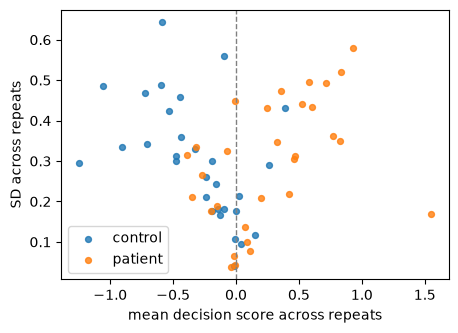

,participant_id,y_true,mean_score,sd_score,n_scores,frac_predicted_patient
21,sub-21,0,-0.589,0.643,5,0.0
49,sub-49,1,0.928,0.580,5,1.0
58,sub-58,0,-0.095,0.561,5,0.4
28,sub-28,1,0.832,0.521,5,1.0
53,sub-53,1,0.582,0.495,5,1.0


In [4]:
X, y, blocks = make_synthetic(n=60, signal="both", effect=0.8, seed=2)
ids = np.array([f"sub-{i:02d}" for i in range(len(y))])
predictions, _, _ = run_nested_cv(X, y, ids, partial(build_models, demo_config(), blocks, include=["mkl"]),
                                  seeds=[11, 23, 37, 41, 53], n_outer=5, n_inner=3, n_jobs=2)
stability = prediction_stability(predictions, "mkl")
fig, ax = plt.subplots(figsize=(5, 3.5))
for label, name in [(0, "control"), (1, "patient")]:
    s = stability[stability["y_true"] == label]
    ax.scatter(s["mean_score"], s["sd_score"], s=18, alpha=0.8, label=name)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("mean decision score across repeats")
ax.set_ylabel("SD across repeats")
ax.legend()
plt.show()
display(stability.sort_values("sd_score", ascending=False).head().round(3))

## Demo 2: correlated features swap weight, and aggregation restores stability
- **Setup:**
  - 200 features in 20 groups of 10;
  - features within a group are near-duplicates ($r \approx 0.99$), like strongly correlated connections within one network;
  - only group 0 carries the diagnostic signal;
  - the model is fitted on 20 different training sets, with weak regularization ($C = 100$, a value the inner CV is allowed to select).
- **Individual weights:** the near-duplicates carry the same information, so each fit divides the weight among them differently. Some individual weights even change sign from one fit to the next.
- **Group sum:** the total weight on the group is stable and always positive, which is why the protocol aggregates to networks and regions.
- **When it happens:** swapping is strongest with near-duplicate features and weak regularization. Strong L2 regularization spreads weight evenly across correlated features, so individual weights are then more stable.

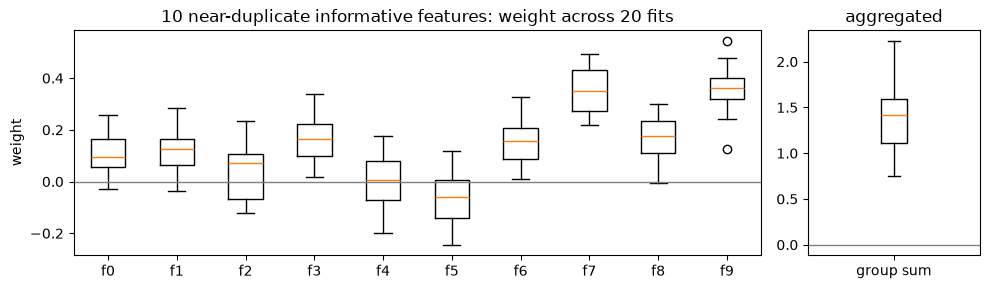

sign consistency, individual features: mean 0.86, worst 0.50
sign consistency, group sum:           1.00
relative variability (SD / |mean|), individual features: 5.10
relative variability (SD / |mean|), group sum:           0.26


In [5]:
rng = np.random.default_rng(3)
n_people, n_groups, per_group = 60, 20, 10
y_g = np.array([0, 1] * (n_people // 2))
latent = rng.normal(size=(n_people, n_groups))
latent[:, 0] += 1.0 * y_g                                    # group 0 carries the signal
X_g = np.repeat(latent, per_group, axis=1) + 0.1 * rng.normal(size=(n_people, n_groups * per_group))  # near-duplicates
blocks_g = {"features": np.arange(n_groups * per_group)}

W = []
for _, seed, fold, train, _ in outer_splits(y_g, 5, seeds=[1, 2, 3, 4]):            # 20 different training sets
    model = KernelSVM("m", blocks_g, ["features"], C_grid=[100.0]).fit(
        X_g[train], y_g[train], inner_splits(y_g[train], 3, seed, fold))
    W.append(model.primal_weights()["features"])
W = np.array(W)
informative = W[:, :per_group]
group_sum = W.reshape(len(W), n_groups, per_group).sum(axis=2)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), gridspec_kw={"width_ratios": [4, 1]})
axes[0].boxplot(informative, tick_labels=[f"f{i}" for i in range(per_group)])
axes[0].axhline(0, color="grey", lw=1)
axes[0].set(title="10 near-duplicate informative features: weight across 20 fits", ylabel="weight")
axes[1].boxplot(group_sum, tick_labels=["group sum"])
axes[1].axhline(0, color="grey", lw=1)
axes[1].set(title="aggregated")
plt.tight_layout()
plt.show()

print(f"sign consistency, individual features: mean {sign_consistency(informative).mean():.2f}, "
      f"worst {sign_consistency(informative).min():.2f}")
print(f"sign consistency, group sum:           {sign_consistency(group_sum[:, None])[0]:.2f}")
print(f"relative variability (SD / |mean|), individual features: "
      f"{np.mean(informative.std(axis=0) / np.abs(informative.mean(axis=0))):.2f}")
print(f"relative variability (SD / |mean|), group sum:           {group_sum.std() / abs(group_sum.mean()):.2f}")

## Demo 3: a confound can masquerade as a diagnostic signal
**How the data are built:**
- the connectivity features contain **no** diagnostic signal;
- patients move more, and motion leaks into every connection.

**Expected pattern:**
- the functional model looks good, but only because of motion;
- the confound-only model does just as well;
- after cross-validated confound regression, the functional model drops to chance.

That pattern is exactly what the confound analyses are designed to detect.

In [6]:
X, y, blocks = make_synthetic(n=100, signal="none", seed=5)
rng = np.random.default_rng(5)
motion = 0.15 + 0.08 * y + 0.04 * rng.normal(size=len(y))            # patients move more
loadings = rng.normal(size=len(blocks["functional"]))
X[:, blocks["functional"]] += 8 * np.outer(motion - motion.mean(), loadings)   # motion leaks into connectivity
X[:, blocks["confounds"][0]] = motion                                  # mean FD is in the confound block
predictions, _, _ = run_nested_cv(
    X, y, np.arange(len(y)),
    partial(build_models, demo_config(), blocks, include=["functional", "confounds_only", "functional_residualized"]),
    seeds=[11, 23], n_outer=5, n_inner=3, n_jobs=2)
display(mean_auc_by_model(predictions).round(3).to_frame("mean outer AUC"))

,mean outer AUC
confounds_only,0.946
functional,0.933
functional_residualized,0.472


## 5. Stated limitations (protocol §10)
- **Single site.** COBRE does not allow leave-one-site-out validation. The strongest supportable claim is generalization to unseen COBRE participants, not transportability to other sites; a second dataset is future work.
- **Sample size.** With $n$ much smaller than the number of functional features ($p \gg n$) and test folds of about 30 participants, every estimate is noisy. The results must be read with this constraint in mind, whatever the metrics turn out to be.
- **Medication and chronicity** are confounded with diagnosis, so the classifier may partly detect treatment or illness duration.
- **Residual motion effects** may remain after censoring and confound regression.
- **Approximate inference.** CV-based intervals are approximate, and the block-permutation null also breaks the dependence between $X_s$ and $X_f$.
- **Analytic choices.** The atlas, denoising and parcellation are fixed choices among several defensible ones, and the sensitivity analyses cover only some of them.
- **Weights are not biology.** Kernel weights and feature weights describe the fitted model, not which modality or region matters biologically.

## Run on the real data
Run this after notebook 05 has produced `results/predictions/predictions.csv` and the primal weights.

In [7]:
USE_REAL_DATA = False

if USE_REAL_DATA:
    display(report_stability())
else:
    print("Synthetic mode: set USE_REAL_DATA = True after running notebooks 05 and 06 on the real data.")

Synthetic mode: set USE_REAL_DATA = True after running notebooks 05 and 06 on the real data.
